In [118]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import value_counts
from setuptools.package_index import unique_values
from sklearn.preprocessing import OneHotEncoder
# from google.colab import files
# uploaded = files.upload()
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, average_precision_score


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [119]:
data = pd.read_csv('HR-Employee-Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,2.0,3.0,Male,61.0,2.0,2.0,Research Scientist,2.0,Married,5130.0,24907.0,1.0,Y,No,23.0,4.0,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,4.0,Male,92.0,2.0,1.0,Laboratory Technician,3.0,Single,2090.0,2396.0,6.0,Y,Yes,15.0,3.0,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,5.0,4.0,Female,56.0,3.0,1.0,Research Scientist,3.0,Married,2909.0,23159.0,1.0,Y,Yes,11.0,3.0,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,1.0,Male,40.0,3.0,1.0,Laboratory Technician,2.0,Married,3468.0,16632.0,9.0,Y,No,12.0,3.0,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [120]:
data.describe()

,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1476 non-null   object 
 1   Attrition                 1476 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

In [122]:
# df = pd.DataFrame(data)
uniqueattr_count = data['Attrition'].value_counts()
print(uniqueattr_count)


Attrition
No        1233
Yes        237
 10:07       1
 15:16       1
 12:15       1
 14:15       1
 10:09       1
 16:24       1
Name: count, dtype: int64


It appears there are some rows with non-relevant data. I will explore the data some more and remove the non valid data.

In [123]:
print(data['Age'].tolist())
data.drop(data[data['Age'].astype(str).str.len()>2].index, inplace = True)# print(data['Age'].tolist())
print(data['Age'].tolist())


['41', '49', '37', '33', '27', '32', '59', '30', '38', '36', '35', '29', '31', '34', '28', '29', '32', '22', '53', '38', '24', '36', '34', '21', '34', '53', '32', '42', '44', '46', '33', '44', '30', '39', '24', '43', '50', '35', '36', '33', '35', '27', '26', '27', '30', '41', '34', '37', '46', '35', '48', '28', '44', '35', '26', '33', '35', '35', '31', '37', '32', '38', '50', '59', '36', '55', '36', '45', '35', '36', '59', '29', '31', '32', '36', '31', '35', '45', '37', '46', '30', '35', '55', '38', '34', '56', '23', '51', '30', '46', '40', '51', '30', '46', '32', '54', '24', '28', '58', '44', '37', '32', '20', '34', '37', '59', '50', '25', '25', '22', '51', '34', '54', '24', '34', '37', '34', '36', '36', '43', '30', '33', '56', '51', '31', '26', '58', '19', '22', '49', '43', '50', '31', '41', '26', '36', '51', '39', '25', '30', '32', '45', '38', '30', '32', '30', '30', '41', '41', '19', '40', '35', '53', '45', '32', '29', '51', '58', '40', '34', '22', '27', '28', '57', '27', '50', '41

In [124]:
data.info()
print('\n')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   object 
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

In [125]:
#Changing age to numerical
data["Age"] = pd.to_numeric(data["Age"])
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

Checking the ratio of attrition for employee


In [126]:
uniqueattr_count = data['Attrition'].value_counts()
print(uniqueattr_count)


Attrition
No     1233
Yes     237
Name: count, dtype: int64


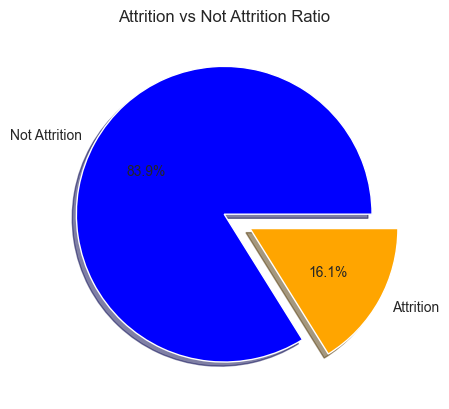

In [127]:

labels = 'Not Attrition' , 'Attrition'
explode = (0,0.2)
# plot
fig, ax = plt.subplots()
ax.pie(data['Attrition'].value_counts(), explode=explode, colors = ['blue','orange'],labels=labels,  autopct='%1.1f%%', shadow=True)
plt.title('Attrition vs Not Attrition Ratio')
plt.show()

In [128]:
data.select_dtypes(exclude="number").columns


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [129]:
# data['OverTime'].value_counts()
for col in data[[ 'Attrition', 'BusinessTravel', 'Department', 'EducationField',
       'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']]:
        print(''
              '--'
              ' ',data[col].value_counts())

--  Attrition
No     1233
Yes     237
Name: count, dtype: int64
--  BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
--  Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
--  EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
--  Gender
Male      882
Female    588
Name: count, dtype: int64
--  JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
--  MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
-

Checking which columns should be encoded, using ordinal or one hot
- Business Travel: Travel_Rarely, Travel_Frequently, Non-Travel

Notes: Over 18 can be dropped since its all Y

In [130]:
#encoding Attrition and Overtime to binary and Business travel to ordinal

data2 = data.copy()
data2["Attrition"] = data2["Attrition"].map({"Yes": 1, "No": 0})
data2['BusinessTravel'] = data2['BusinessTravel'].map({"Travel_Rarely": 1, "Travel_Frequently": 2, "Non-Travel":0})
data2['OverTime'] = data2['OverTime'].map({"Yes":1, "No":0})

# data2.head()



In [131]:
data2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   int64  
 2   BusinessTravel            1470 non-null   int64  
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

In [132]:
data2.select_dtypes(exclude="number").columns


Index(['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus',
       'Over18'],
      dtype='object')

In [133]:
#removing Employee count,emplpoyee number, over 18, and Standard Hours since they have a consistent value across all rows
data2 = data2.drop(columns =['EmployeeCount','EmployeeNumber','StandardHours','Over18'])


In [134]:
data2.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,1,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49,0,2,279.0,Research & Development,8.0,1.0,Life Sciences,3.0,Male,61.0,2.0,2.0,Research Scientist,2.0,Married,5130.0,24907.0,1.0,0,23.0,4.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37,1,1,1373.0,Research & Development,2.0,2.0,Other,4.0,Male,92.0,2.0,1.0,Laboratory Technician,3.0,Single,2090.0,2396.0,6.0,1,15.0,3.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33,0,2,1392.0,Research & Development,3.0,4.0,Life Sciences,4.0,Female,56.0,3.0,1.0,Research Scientist,3.0,Married,2909.0,23159.0,1.0,1,11.0,3.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27,0,1,591.0,Research & Development,2.0,1.0,Medical,1.0,Male,40.0,3.0,1.0,Laboratory Technician,2.0,Married,3468.0,16632.0,9.0,0,12.0,3.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [135]:
corr = data2.select_dtypes(include="number").corr()
corr

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,-0.011807,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.028062,0.003634,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,0.127006,-0.056652,0.077924,-0.031373,-0.103369,-0.006846,-0.130016,-0.169105,-0.103481,-0.159840,0.015170,0.043494,0.246118,-0.013478,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
BusinessTravel,-0.011807,0.127006,1.000000,-0.015539,-0.009696,-0.008670,-0.011310,-0.004164,0.029300,-0.011696,0.008666,-0.013450,-0.008440,-0.030743,0.042752,-0.025727,0.001683,0.008926,-0.028257,0.007972,0.016357,0.004209,0.005212,-0.005336,0.005222,-0.000229
DailyRate,0.010661,-0.056652,-0.015539,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.009135,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,0.077924,-0.009696,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.025514,0.040235,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,-0.008670,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.020322,-0.011111,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,-0.103369,-0.011310,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,0.070132,-0.031701,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,-0.006846,-0.004164,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.007782,-0.009062,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,-0.130016,0.029300,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.003507,-0.017205,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,-0.169105,-0.011696,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,0.000544,-0.034730,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


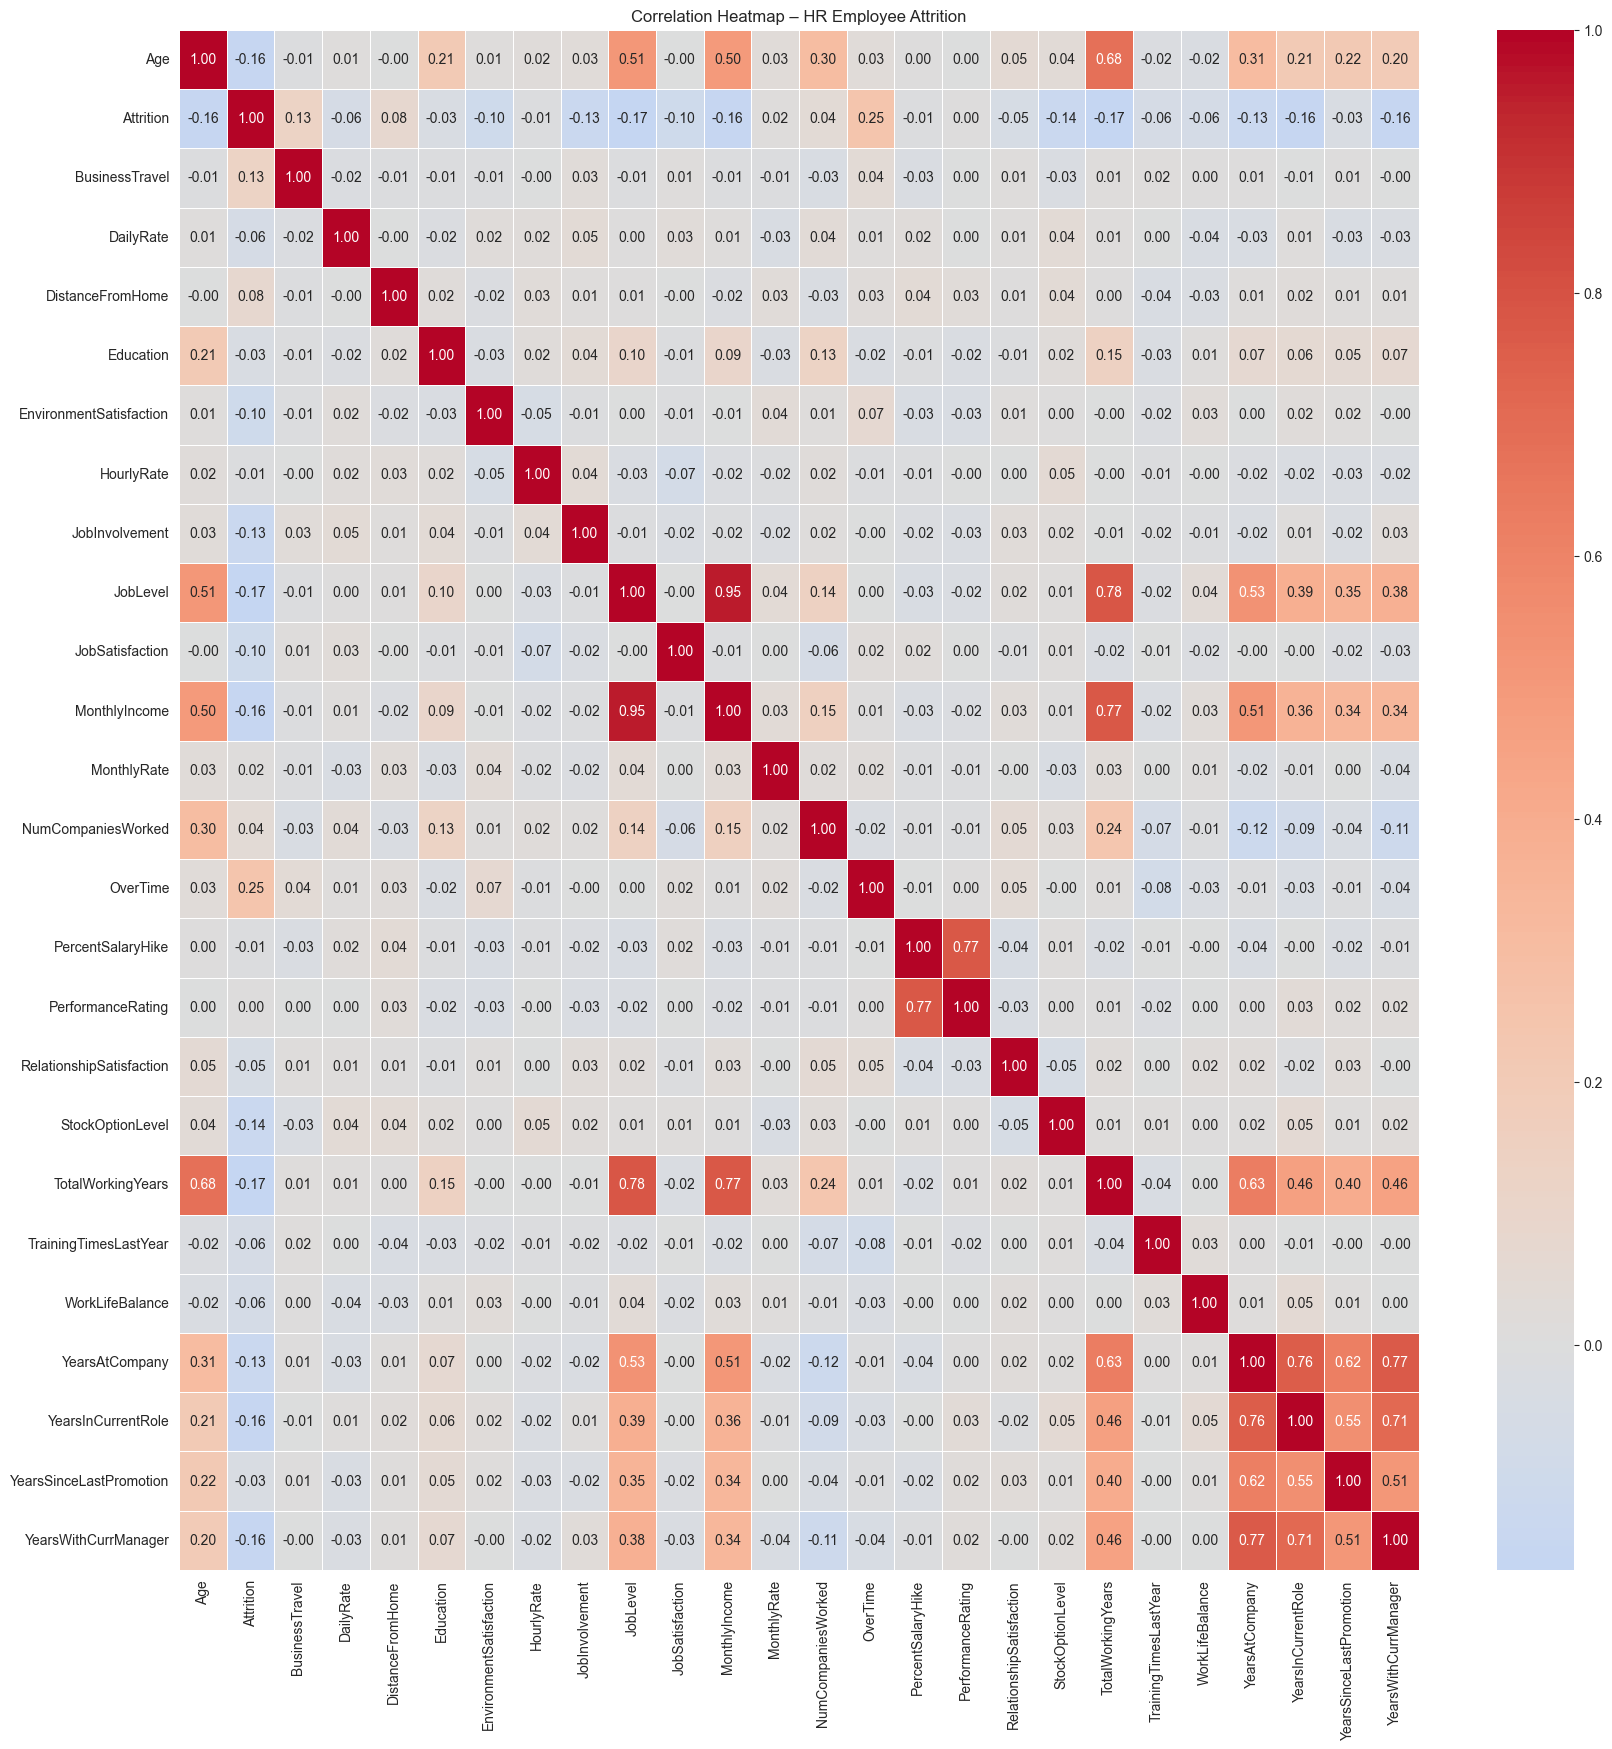

In [136]:
# changing to heatmap

# plt.figure(figsize=(20, 20))
plt.figure(figsize=(20,20))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt = ".2f"
)
plt.title("Correlation Heatmap – HR Employee Attrition")
plt.show()

In [137]:
# Display the categorical attributes
data2.select_dtypes(exclude="number").columns


Index(['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus'], dtype='object')

In [138]:
data2.loc[:,['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']].head()

,Department,EducationField,Gender,JobRole,MaritalStatus
0,Sales,Life Sciences,Female,Sales Executive,Single
1,Research & Development,Life Sciences,Male,Research Scientist,Married
2,Research & Development,Other,Male,Laboratory Technician,Single
3,Research & Development,Life Sciences,Female,Research Scientist,Married
4,Research & Development,Medical,Male,Laboratory Technician,Married


In [139]:
data2.dtypes

Age                           int64
Attrition                     int64
BusinessTravel                int64
DailyRate                   float64
Department                   object
DistanceFromHome            float64
Education                   float64
EducationField               object
EnvironmentSatisfaction     float64
Gender                       object
HourlyRate                  float64
JobInvolvement              float64
JobLevel                    float64
JobRole                      object
JobSatisfaction             float64
MaritalStatus                object
MonthlyIncome               float64
MonthlyRate                 float64
NumCompaniesWorked          float64
OverTime                      int64
PercentSalaryHike           float64
PerformanceRating           float64
RelationshipSatisfaction    float64
StockOptionLevel            float64
TotalWorkingYears           float64
TrainingTimesLastYear       float64
WorkLifeBalance             float64
YearsAtCompany              

Encode the remaining categorical columns

In [140]:
data2encode = data2[['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']]
data2encode.head()

,Department,EducationField,Gender,JobRole,MaritalStatus
0,Sales,Life Sciences,Female,Sales Executive,Single
1,Research & Development,Life Sciences,Male,Research Scientist,Married
2,Research & Development,Other,Male,Laboratory Technician,Single
3,Research & Development,Life Sciences,Female,Research Scientist,Married
4,Research & Development,Medical,Male,Laboratory Technician,Married


In [141]:
encoder = OneHotEncoder(handle_unknown='ignore')
encodeddata = encoder.fit_transform(data2[['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']]).toarray()
encodeddf = pd.DataFrame(encodeddata, columns=encoder.get_feature_names_out(['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']))
encodeddf.head()


,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [142]:
#Join the new columns to original DF
#first drop the columns
data3 = data2.copy()
data3 = data2.drop(columns =['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus'])
data3.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,1,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49,0,2,279.0,8.0,1.0,3.0,61.0,2.0,2.0,2.0,5130.0,24907.0,1.0,0,23.0,4.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37,1,1,1373.0,2.0,2.0,4.0,92.0,2.0,1.0,3.0,2090.0,2396.0,6.0,1,15.0,3.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33,0,2,1392.0,3.0,4.0,4.0,56.0,3.0,1.0,3.0,2909.0,23159.0,1.0,1,11.0,3.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27,0,1,591.0,2.0,1.0,1.0,40.0,3.0,1.0,2.0,3468.0,16632.0,9.0,0,12.0,3.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [143]:
data3encoded = pd.concat([data3,encodeddf], axis=1)
data3encoded.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,1,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,2,279.0,8.0,1.0,3.0,61.0,2.0,2.0,2.0,5130.0,24907.0,1.0,0,23.0,4.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,37,1,1,1373.0,2.0,2.0,4.0,92.0,2.0,1.0,3.0,2090.0,2396.0,6.0,1,15.0,3.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,33,0,2,1392.0,3.0,4.0,4.0,56.0,3.0,1.0,3.0,2909.0,23159.0,1.0,1,11.0,3.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,27,0,1,591.0,2.0,1.0,1.0,40.0,3.0,1.0,2.0,3468.0,16632.0,9.0,0,12.0,3.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [144]:
data3encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   BusinessTravel                     1470 non-null   int64  
 3   DailyRate                          1470 non-null   float64
 4   DistanceFromHome                   1470 non-null   float64
 5   Education                          1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   HourlyRate                         1470 non-null   float64
 8   JobInvolvement                     1470 non-null   float64
 9   JobLevel                           1470 non-null   float64
 10  JobSatisfaction                    1470 non-null   float64
 11  MonthlyIncome                      1470 non-null   float

In [145]:
corr2 = data3encoded.corr()
corr2

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
Age,1.000000,-0.159205,-0.011807,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.028062,0.003634,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,0.020523,0.017883,-0.027549,0.001696,0.016824,0.038162,-0.006354,-0.041466,-0.027604,0.036311,-0.036311,0.098825,-0.029856,-0.143176,0.294248,0.049726,0.185891,-0.146518,-0.002001,-0.175785,0.033120,0.083919,-0.119185
Attrition,-0.159205,1.000000,0.127006,-0.056652,0.077924,-0.031373,-0.103369,-0.006846,-0.130016,-0.169105,-0.103481,-0.159840,0.015170,0.043494,0.246118,-0.013478,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199,0.016832,-0.085293,0.080855,0.036466,-0.032703,0.055781,-0.046999,-0.017898,0.069355,-0.029453,0.029453,-0.078696,0.036215,0.098290,-0.083316,-0.082994,-0.088870,-0.000360,0.019774,0.157234,-0.087716,-0.090984,0.175419
BusinessTravel,-0.011807,0.127006,1.000000,-0.015539,-0.009696,-0.008670,-0.011310,-0.004164,0.029300,-0.011696,0.008666,-0.013450,-0.008440,-0.030743,0.042752,-0.025727,0.001683,0.008926,-0.028257,0.007972,0.016357,0.004209,0.005212,-0.005336,0.005222,-0.000229,-0.002796,0.005308,-0.004261,-0.003168,0.019860,0.005201,-0.011245,-0.000470,-0.019699,0.044896,-0.044896,-0.001426,0.010435,0.002094,-0.039312,0.014893,-0.005138,0.002477,-0.025131,0.059995,-0.028444,0.002198,0.023017
DailyRate,0.010661,-0.056652,-0.015539,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.009135,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,-0.026726,0.014871,-0.003616,-0.043144,0.004028,-0.064449,0.034202,-0.003893,0.030869,0.011716,-0.011716,0.040141,-0.021156,-0.006728,-0.013224,-0.005302,-0.000021,-0.002624,-0.000513,0.005375,0.037080,0.040035,-0.075835
DistanceFromHome,-0.001686,0.077924,-0.009696,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.025514,0.040235,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,-0.012901,-0.008117,0.014085,-0.002624,-0.024499,0.039294,0.013486,-0.007969,-0.014802,0.001851,-0.001851,0.022916,-0.024089,0.012369,-0.039190,0.011848,-0.022351,-0.010986,0.030761,-0.015994,-0.005440,0.030232,-0.027445
Education,0.208034,-0.031373,-0.008670,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.020322,-0.011111,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,0.011435,-0.018604,0.014215,0.026479,0.013184,0.072405,-0.072335,0.038043,-0.026742,0.016547,-0.016547,0.024270,-0.005295,-0.063566,0.028453,-0.005290,0.049694,0.000709,0.053398,-0.091465,-0.002439,-0.001865,0.004168
EnvironmentSatisfaction,0.010146,-0.103369,-0.011310,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,0.070132

In [146]:
corrtest = data3encoded.corr().abs()
corrtest

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
Age,1.000000,0.159205,0.011807,0.010661,0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,0.004892,0.497855,0.028051,0.299635,0.028062,0.003634,0.001904,0.053535,0.037510,0.680381,0.019621,0.021490,0.311309,0.212901,0.216513,0.202089,0.020523,0.017883,0.027549,0.001696,0.016824,0.038162,0.006354,0.041466,0.027604,0.036311,0.036311,0.098825,0.029856,0.143176,0.294248,0.049726,0.185891,0.146518,0.002001,0.175785,0.033120,0.083919,0.119185
Attrition,0.159205,1.000000,0.127006,0.056652,0.077924,0.031373,0.103369,0.006846,0.130016,0.169105,0.103481,0.159840,0.015170,0.043494,0.246118,0.013478,0.002889,0.045872,0.137145,0.171063,0.059478,0.063939,0.134392,0.160545,0.033019,0.156199,0.016832,0.085293,0.080855,0.036466,0.032703,0.055781,0.046999,0.017898,0.069355,0.029453,0.029453,0.078696,0.036215,0.098290,0.083316,0.082994,0.088870,0.000360,0.019774,0.157234,0.087716,0.090984,0.175419
BusinessTravel,0.011807,0.127006,1.000000,0.015539,0.009696,0.008670,0.011310,0.004164,0.029300,0.011696,0.008666,0.013450,0.008440,0.030743,0.042752,0.025727,0.001683,0.008926,0.028257,0.007972,0.016357,0.004209,0.005212,0.005336,0.005222,0.000229,0.002796,0.005308,0.004261,0.003168,0.019860,0.005201,0.011245,0.000470,0.019699,0.044896,0.044896,0.001426,0.010435,0.002094,0.039312,0.014893,0.005138,0.002477,0.025131,0.059995,0.028444,0.002198,0.023017
DailyRate,0.010661,0.056652,0.015539,1.000000,0.004985,0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,0.032182,0.038153,0.009135,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,0.037848,0.034055,0.009932,0.033229,0.026363,0.026726,0.014871,0.003616,0.043144,0.004028,0.064449,0.034202,0.003893,0.030869,0.011716,0.011716,0.040141,0.021156,0.006728,0.013224,0.005302,0.000021,0.002624,0.000513,0.005375,0.037080,0.040035,0.075835
DistanceFromHome,0.001686,0.077924,0.009696,0.004985,1.000000,0.021042,0.016075,0.031131,0.008783,0.005303,0.003669,0.017014,0.027473,0.029251,0.025514,0.040235,0.027110,0.006557,0.044872,0.004628,0.036942,0.026556,0.009508,0.018845,0.010029,0.014406,0.012901,0.008117,0.014085,0.002624,0.024499,0.039294,0.013486,0.007969,0.014802,0.001851,0.001851,0.022916,0.024089,0.012369,0.039190,0.011848,0.022351,0.010986,0.030761,0.015994,0.005440,0.030232,0.027445
Education,0.208034,0.031373,0.008670,0.016806,0.021042,1.000000,0.027128,0.016775,0.042438,0.101589,0.011296,0.094961,0.026084,0.126317,0.020322,0.011111,0.024539,0.009118,0.018422,0.148280,0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,0.011435,0.018604,0.014215,0.026479,0.013184,0.072405,0.072335,0.038043,0.026742,0.016547,0.016547,0.024270,0.005295,0.063566,0.028453,0.005290,0.049694,0.000709,0.053398,0.091465,0.002439,0.001865,0.004168
EnvironmentSatisfaction,0.010146,0.103369,0.011310,0.018355,0.016075,0.027128,1.000000,0.049857,0.008278,0.001212,0.006784,0.006259,0.037600,0.012594,0.070132,0.031701,0.029548,0.007665,0.003432,0.002693,0.019359,0.027627,0.001458,0.018007,0.016194,0.004999,0.007597,0.027976,0.025606,0.006898,0.024526,0.00

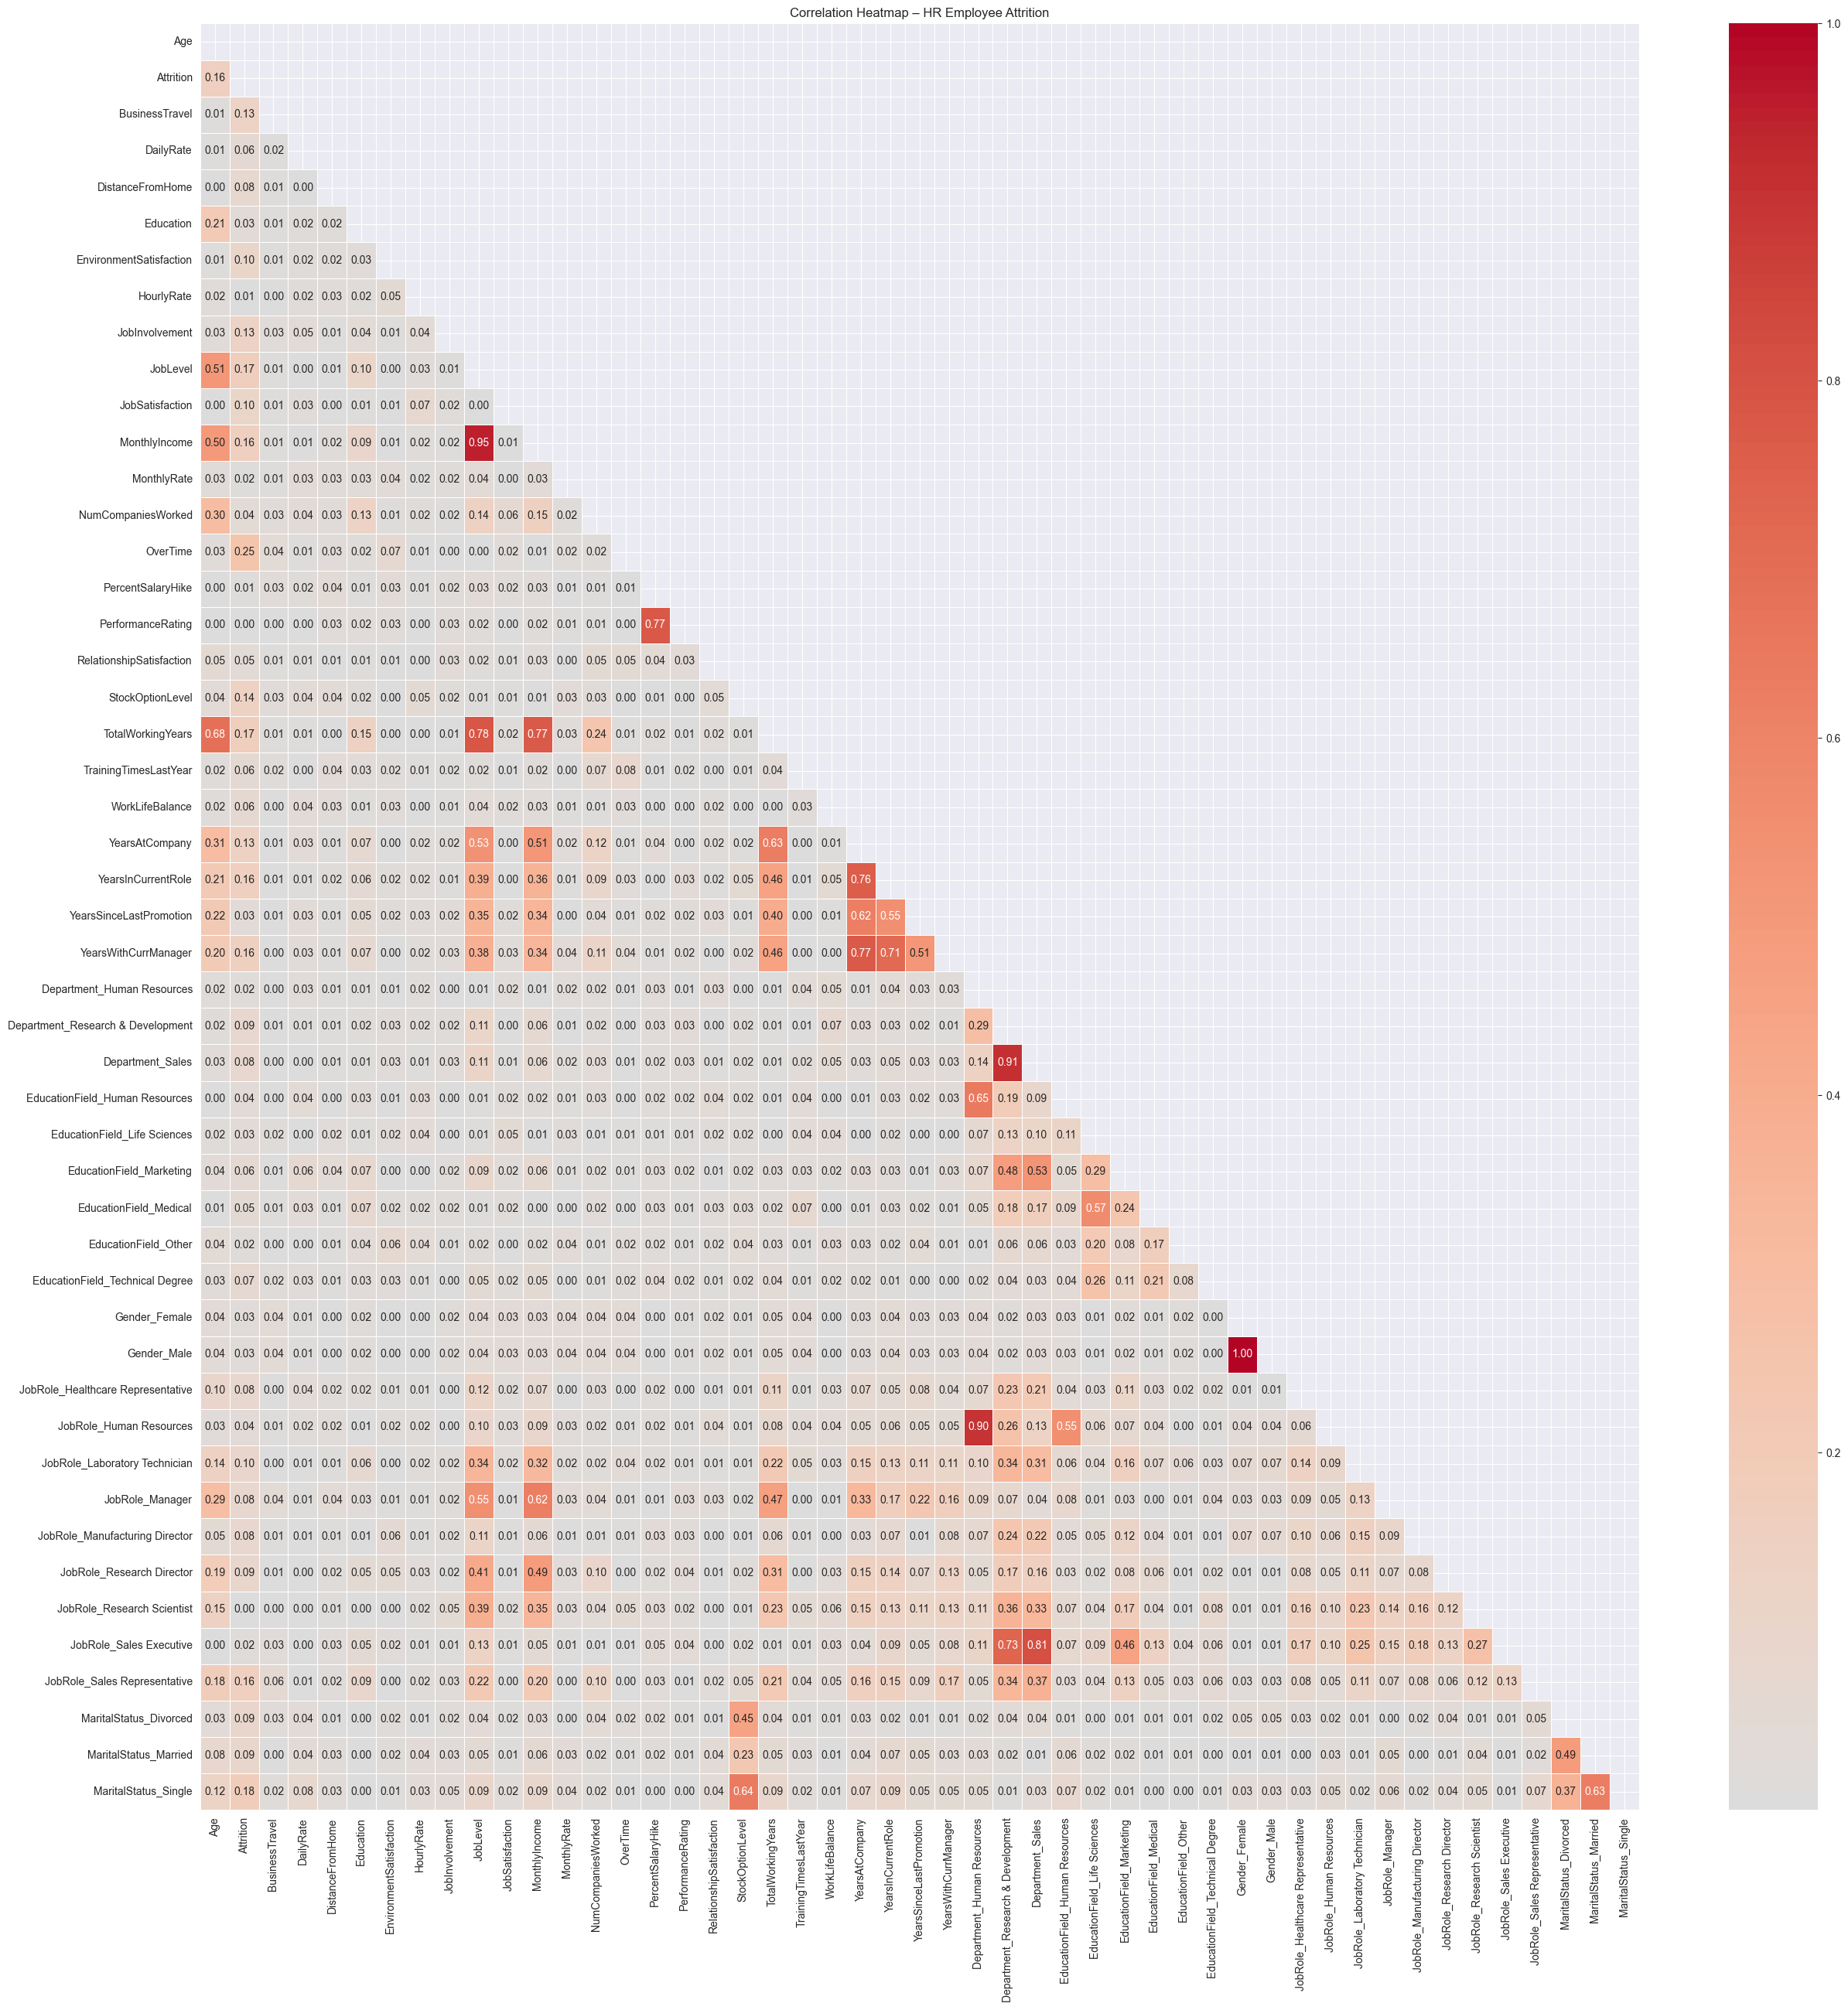

In [147]:
plt.figure(figsize=(30, 30))
mask = np.triu(np.ones_like(corrtest, dtype=bool))
sns.heatmap(
    corrtest,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    mask=mask
)
plt.title("Correlation Heatmap – HR Employee Attrition")
plt.show()

Variables with high correlation are:


In [148]:
upper_triangle = corrtest.where(np.triu(np.ones(corrtest.shape), k=1).astype(np.bool_))
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column]>0.9)]
print(features_to_drop)

['MonthlyIncome', 'Department_Sales', 'Gender_Male', 'JobRole_Human Resources']


In [149]:
data3encoded[["Gender_Female","Gender_Male"]].head(10)


,Gender_Female,Gender_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
5,0.0,1.0
6,1.0,0.0
7,0.0,1.0
8,0.0,1.0
9,0.0,1.0


In [150]:
(data3encoded['Gender_Female'] == data3encoded['Gender_Male']).mean()


np.float64(0.0)

In [151]:
data3encoded[['Gender_Female','Gender_Male']].sum()


Gender_Female    588.0
Gender_Male      882.0
dtype: float64

In [152]:
data3encoded[['Gender_Female','Gender_Male']].corr()

,Gender_Female,Gender_Male
Gender_Female,1.0,-1.0
Gender_Male,-1.0,1.0


Im seeing that Gender Male has a correlation of 1 to Female. Gender is a binary variable, only has 2 labels. After closer review, it appears we can drop 1 to have a dummy column as they are perfectly inverse to each other. I will move forward with dropping Male as it is showing correlation of 1 to Female.

I will also explore other feature importance selection besides only correlation since I have a lot of categorical data.

https://stackoverflow.com/questions/43515877/should-binary-features-be-one-hot-encoded

https://www.kaggle.com/discussions/getting-started/114797

In [153]:
len(data3encoded.columns)

49

In [154]:
data3encoded2 = data3encoded.drop(columns =['Gender_Male'])
data3encoded2.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,1,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,2,279.0,8.0,1.0,3.0,61.0,2.0,2.0,2.0,5130.0,24907.0,1.0,0,23.0,4.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,37,1,1,1373.0,2.0,2.0,4.0,92.0,2.0,1.0,3.0,2090.0,2396.0,6.0,1,15.0,3.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,33,0,2,1392.0,3.0,4.0,4.0,56.0,3.0,1.0,3.0,2909.0,23159.0,1.0,1,11.0,3.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,27,0,1,591.0,2.0,1.0,1.0,40.0,3.0,1.0,2.0,3468.0,16632.0,9.0,0,12.0,3.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [155]:
len(data3encoded2.columns)

48

In [156]:
data3encoded2.to_csv('data3encoded2.csv')
#data3encoded2 holds all numerical data after hot encoding
#data holds data before any changes to categories other than initial cleaning

We will start analysis with Frequent Pattern analysis, focusing only on binary columns.

In [157]:
#selecting only binary/hot encoded columns

data_apriori = data3encoded2[['Attrition','OverTime','Department_Human Resources','Department_Research & Development','Department_Sales','EducationField_Human Resources','EducationField_Life Sciences','EducationField_Marketing','EducationField_Medical','EducationField_Other','EducationField_Technical Degree','Gender_Female','JobRole_Healthcare Representative','JobRole_Human Resources','JobRole_Laboratory Technician','JobRole_Manager','JobRole_Manufacturing Director','JobRole_Research Director','JobRole_Research Scientist','JobRole_Sales Executive','JobRole_Sales Representative','MaritalStatus_Divorced','MaritalStatus_Married','MaritalStatus_Single']]

In [158]:
data_apriori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Attrition                          1470 non-null   int64  
 1   OverTime                           1470 non-null   int64  
 2   Department_Human Resources         1470 non-null   float64
 3   Department_Research & Development  1470 non-null   float64
 4   Department_Sales                   1470 non-null   float64
 5   EducationField_Human Resources     1470 non-null   float64
 6   EducationField_Life Sciences       1470 non-null   float64
 7   EducationField_Marketing           1470 non-null   float64
 8   EducationField_Medical             1470 non-null   float64
 9   EducationField_Other               1470 non-null   float64
 10  EducationField_Technical Degree    1470 non-null   float64
 11  Gender_Female                      1470 non-null   float

In [159]:
data_apriori.head()

,Attrition,OverTime,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [160]:
#Code for Apriori
X = data_apriori.astype(bool)
freq_itemsets = apriori(X, min_support=0.1,use_colnames=True)
freq_itemsets = freq_itemsets.sort_values(by='support', ascending=False,ignore_index=True)
print(freq_itemsets)


     support                                           itemsets
0   0.653741                (Department_Research & Development)
1   0.457823                            (MaritalStatus_Married)
2   0.412245                     (EducationField_Life Sciences)
3   0.400000                                    (Gender_Female)
4   0.319728                             (MaritalStatus_Single)
5   0.315646                           (EducationField_Medical)
6   0.303401                                 (Department_Sales)
7   0.299320  (Department_Research & Development, EducationF...
8   0.294558  (MaritalStatus_Married, Department_Research & ...
9   0.282993                                         (OverTime)
10  0.257823  (Gender_Female, Department_Research & Developm...
11  0.246939  (Department_Research & Development, EducationF...
12  0.222449                           (MaritalStatus_Divorced)
13  0.221769                          (JobRole_Sales Executive)
14  0.221769        (JobRole_Sales Execu

In [161]:
#Association Rules

rules = association_rules(freq_itemsets,metric="confidence", min_threshold=0.2)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Department_Research & Development),(EducationField_Life Sciences),0.653741,0.412245,0.299320,0.457856,1.110642,1.0,0.029818,1.084132,0.287703,0.390417,0.077603,0.591965
1,(EducationField_Life Sciences),(Department_Research & Development),0.412245,0.653741,0.299320,0.726073,1.110642,1.0,0.029818,1.264052,0.169492,0.390417,0.208893,0.591965
2,(MaritalStatus_Married),(Department_Research & Development),0.457823,0.653741,0.294558,0.643388,0.984162,1.0,-0.004740,0.970967,-0.028826,0.360533,-0.029902,0.546980
3,(Department_Research & Development),(MaritalStatus_Married),0.653741,0.457823,0.294558,0.450572,0.984162,1.0,-0.004740,0.986803,-0.044411,0.360533,-0.013374,0.546980
4,(Gender_Female),(Department_Research & Development),0.400000,0.653741,0.257823,0.644558,0.985952,1.0,-0.003673,0.974163,-0.023196,0.323932,-0.026523,0.519469
5,(Department_Research & Development),(Gender_Female),0.653741,0.400000,0.257823,0.394381,0.985952,1.0,-0.003673,0.990722,-0.039522,0.323932,-0.009365,0.519469
6,(Department_Research & Development),(EducationField_Medical),0.653741,0.315646,0.246939,0.377732,1.196693,1.0,0.040588,1.099772,0.474684,0.341808,0.090721,0.580030
7,(EducationField_Medical),(Department_Research & Development),0.315646,0.653741,0.246939,0.782328,1.196693,1.0,0.040588,1.590732,0.240173,0.341808,0.371359,0.580030
8,(JobRole_Sales Executive),(Department_Sales),0.221769,0.303401,0.221769,1.000000,3.295964,1.0,0.154484,inf,0.895105,0.730942,1.000000,0.865471
9,(Department_Sales),(JobRole_Sales Executive),0.303401,0.221769,0.221769,0.730942,3.295964,1.0,0.154484,2.892426,1.000000,0.730942,0.654269,0.865471


In [162]:
#Look for results where Attrition was a conesequent
attrition_rules = rules[
    rules['consequents'].apply(lambda x: 'Attrition' in x)
]
attrition_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


No results so we are going to lower the support and min threshold for confidence

In [163]:
X = data_apriori.astype(bool)
freq_itemsets = apriori(X, min_support=0.03,use_colnames=True)
# freq_itemsets = freq_itemsets.sort_values(by='support', ascending=False,ignore_index=True)
# print(freq_itemsets)

rules = association_rules(freq_itemsets,metric="confidence", min_threshold=0.2)

attrition_rules = rules[
    rules['consequents'].apply(lambda x: 'Attrition' in x)
]
attrition_rules = attrition_rules.sort_values(by='lift', ascending=False,ignore_index=True)
attrition_rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(OverTime, MaritalStatus_Single)",(Attrition),0.089116,0.161224,0.044218,0.496183,3.077592,1.0,0.029850,1.664842,0.741116,0.214521,0.399343,0.385222
1,(JobRole_Laboratory Technician),"(Attrition, Department_Research & Development)",0.176190,0.090476,0.042177,0.239382,2.645804,1.0,0.026236,1.195770,0.755081,0.187879,0.163719,0.352774
2,"(OverTime, Department_Sales)",(Attrition),0.087075,0.161224,0.032653,0.375000,2.325949,1.0,0.018614,1.342041,0.624441,0.151420,0.254866,0.288766
3,"(Department_Sales, MaritalStatus_Single)",(Attrition),0.104082,0.161224,0.036054,0.346405,2.148589,1.0,0.019274,1.283327,0.596682,0.157270,0.220775,0.285017
4,"(OverTime, EducationField_Life Sciences)",(Attrition),0.113605,0.161224,0.034694,0.305389,1.894186,1.0,0.016378,1.207548,0.532572,0.144476,0.171875,0.260290
5,(OverTime),(Attrition),0.282993,0.161224,0.086395,0.305288,1.893561,1.0,0.040769,1.207372,0.658145,0.241445,0.171755,0.420577
6,"(OverTime, Department_Research & Development)",(Attrition),0.184354,0.161224,0.050340,0.273063,1.693680,1.0,0.020618,1.153849,0.502141,0.170507,0.133335,0.292650
7,"(OverTime, Gender_Female)",(Attrition),0.122449,0.161224,0.031973,0.261111,1.619550,1.0,0.012231,1.135185,0.435923,0.127027,0.119086,0.229712
8,(MaritalStatus_Single),(Attrition),0.319728,0.161224,0.081633,0.255319,1.583625,1.0,0.030085,1.126356,0.541750,0.204429,0.112181,0.380824
9,"(MaritalStatus_Single, EducationField_Life Sci...",(Attrition),0.136735,0.161224,0.033333,0.243781,1.512060,1.0,0.011288,1.109170,0.392290,0.125964,0.098425,0.225266


Interesting find:
Overtime & Single employees are 3 times more likely to leave (3.077 lift), 49.6% left

* 8.91% of employees are Single + OverTime
* (antecedent support = 0.089116)

* 4.42% of all employees are Single + OverTime AND left
* (support = 0.044218)

* Among Single + OverTime employees, 49.6% left
* (confidence = 0.496)

* They are 3.07× more likely to leave than average
* (lift = 3.07)


We will now move to supervised learning

In [164]:
from sklearn.model_selection import train_test_split
# Target / features
y = data3encoded2["Attrition"].astype(int)
X = data3encoded2.drop(columns=["Attrition"])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Attrition rate overall:", y.mean())

Train shape: (1176, 47) Test shape: (294, 47)
Attrition rate overall: 0.16122448979591836


In [165]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1176, 47)
Test shape: (294, 47)


Will also create a SMOTE version to be used for comparison

In [166]:
from imblearn.over_sampling import SMOTE
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)



smote = SMOTE()
X_sm, y_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_sm.value_counts())




Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [167]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.feature_selection import SelectFromModel
#
# selector = SelectFromModel(
#     LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced")
# )
# X_train_sel = selector.fit_transform(X_train, y_train)
# X_test_sel  = selector.transform(X_test)
#
# selected_mask = selector.get_support()
# selected_features = X_train.columns[selected_mask]
# print("Selected feature count:", selected_mask.sum())
# print("First 20 selected features:", list(selected_features[:]))


Now that we have the test and train data split we can move to the first supervised model, Logistic Regression.

In [168]:
    from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, average_precision_score)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

log_reg_standard = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))])

log_reg_standard.fit(X_train, y_train)

proba = log_reg_standard.predict_proba(X_test)[:, 1]
pred  = log_reg_standard.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))



ROC-AUC: 0.8084244982341288
PR-AUC (Avg Precision): 0.569651514586499

Confusion matrix:
 [[236  11]
 [ 30  17]]

Report:
               precision    recall  f1-score   support

           0      0.887     0.955     0.920       247
           1      0.607     0.362     0.453        47

    accuracy                          0.861       294
   macro avg      0.747     0.659     0.687       294
weighted avg      0.842     0.861     0.845       294



In [169]:
    from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, average_precision_score)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

log_reg_balanced = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])

log_reg_balanced.fit(X_train, y_train)

proba = log_reg_balanced.predict_proba(X_test)[:, 1]
pred  = log_reg_balanced.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))



ROC-AUC: 0.7991213713498149
PR-AUC (Avg Precision): 0.541359474242598

Confusion matrix:
 [[193  54]
 [ 17  30]]

Report:
               precision    recall  f1-score   support

           0      0.919     0.781     0.845       247
           1      0.357     0.638     0.458        47

    accuracy                          0.759       294
   macro avg      0.638     0.710     0.651       294
weighted avg      0.829     0.759     0.783       294



Results:
**Precision Recall - Area under Curve**: .541. High since baseline is .16, The model has high false positives.
**Receiver Operation Characteristic - Area under Curve**: .799. Its moderate at identifying separate classes.

**Confusion matrix:**
True Negative - 193
False Positive - 54
False Negative - 17
True Positive - 30

**Report**
Class 0 (No attrition): Precision .919 is high. Recall .781 which is a bit low considering baseline attrition is 84%. F1 .845.
Class 1 (Attrition): Precision .357 very low. Recall .638 very low. F1 .458.
Accuracy is .759 but it is high due to Class 0.



We see that recall for Attrition is quite low. Since we are more interested in trying to identify which employees will leave, Recall is the most important metric for this project. Recall tells us how well the model did at identifying employees who actually attrited.
The model already does a good job at identifying employees who stay.
Due to our imbalanced data, we have a couple of options. We can balance it using options like SMOTE which artificially upsamples positives, we can change model weight features to account for the imbalance, or downsample.
I believe the best option for this data is to use a Threshold instead. This way we can void adding synthetic data to our data sets and we can fine tune it to reach a desired Recall.
The default threshold for models is 50%. However, this seems to be too conservative in identifying true positives. We can update the threshold to something lower than 50%, which will capture more True Positives along with False Positives. However, the cost of missing True Positives is more costly than the alternative.
Ref https://www.ultralytics.com/blog/accuracy-precision-recall#:~:text=Common%20evaluation%20metrics%20include%20accuracy%20(overall%20correctness)%2C,a%20different%20part%20of%20a%20model's%20behavior.

Logistic Regression with SMOTE

In [170]:
log_reg_smote = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])

log_reg_smote.fit(X_sm, y_sm)

proba = log_reg_smote.predict_proba(X_test)[:, 1]
pred  = log_reg_smote.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

ROC-AUC: 0.7484710138685503
PR-AUC (Avg Precision): 0.4330359479965782

Confusion matrix:
 [[184  63]
 [ 18  29]]

Report:
               precision    recall  f1-score   support

           0      0.911     0.745     0.820       247
           1      0.315     0.617     0.417        47

    accuracy                          0.724       294
   macro avg      0.613     0.681     0.618       294
weighted avg      0.816     0.724     0.755       294



LR with SMOTE is worse than original set


First we will create a helper function which will determine the best threshold based on target recall.

In [171]:
from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        precision_recall_curve,
        roc_auc_score,
        average_precision_score,
    )

def evaluate_with_threshold(model, X_test, y_test, target_recall=0.70):
    #if I want to add plot add plot_cm=True

    # Get predicted probabilities
    proba = model.predict_proba(X_test)[:, 1]

    # Compute PR curve
    precision, recall, thresholds = precision_recall_curve(y_test, proba)

    # Find threshold closest to desired recall
    idx = np.argmin(np.abs(recall - target_recall))
    best_threshold = thresholds[max(idx-1, 0)]

    # Generate predictions using this threshold
    preds = (proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, preds)
    cm_df = pd.DataFrame(cm, index=["Actual: No Attr", "Actual: Attr"], columns=["Pred: No Attr", "Pred: Attr"])


    print("====================================")
    print(f"Chosen Threshold: {best_threshold:.3f}")
    print(f"Target Recall: {target_recall}")
    print("====================================")

    print("\nConfusion Matrix (thresholded):\n", cm_df.to_string())
    print("")

    # if plot_cm:
    #     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    #     disp.plot(cmap="Blues", values_format="d")
    #     plt.title(f"Confusion Matrix @ threshold={best_threshold:.3f}")
    #     plt.show()


    print("ROC-AUC:", roc_auc_score(y_test, proba))
    print("PR-AUC:", average_precision_score(y_test, proba))
    print("\nClassification Report:\n")
    print(classification_report(y_test, preds))
    plt.plot(thresholds, recall[:-1])
    plt.xlabel("Threshold")
    plt.ylabel("Recall")
    plt.title("Recall vs Threshold")
    plt.show()



    return best_threshold




We can then use the helper function to run each of the models with the best thresholds.

Chosen Threshold: 0.115
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            181          66
Actual: Attr                13          34

ROC-AUC: 0.8084244982341288
PR-AUC: 0.569651514586499

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.73      0.82       247
           1       0.34      0.72      0.46        47

    accuracy                           0.73       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.73      0.76       294



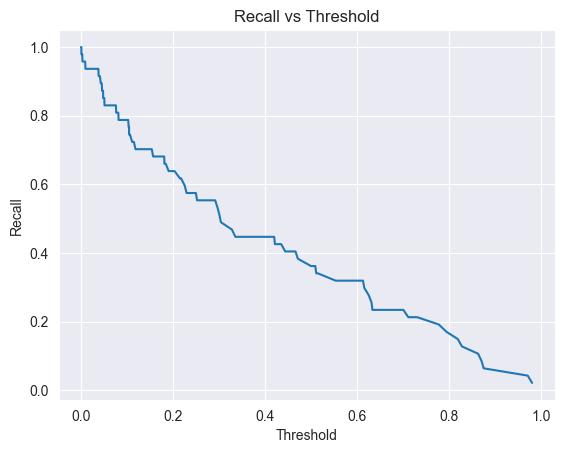

In [172]:

best_thr = evaluate_with_threshold(log_reg_standard, X_test, y_test, target_recall=.70)


Feature importance


In [173]:
coef_df = pd.DataFrame(
    log_reg_balanced.named_steps['model'].coef_.T,
    index=X_train.columns,
    columns=['coefficient']
).sort_values('coefficient', ascending=False)
print(coef_df.head(20))



                                   coefficient
OverTime                              0.771763
JobLevel                              0.654995
YearsSinceLastPromotion               0.490378
JobRole_Human Resources               0.472238
NumCompaniesWorked                    0.460842
JobRole_Laboratory Technician         0.455883
BusinessTravel                        0.455803
JobRole_Sales Representative          0.341042
DistanceFromHome                      0.318005
YearsAtCompany                        0.257415
MaritalStatus_Single                  0.234504
EducationField_Human Resources        0.180204
EducationField_Technical Degree       0.153911
Department_Sales                      0.150452
PerformanceRating                     0.141440
Department_Research & Development     0.046291
EducationField_Marketing              0.035628
MonthlyRate                           0.029857
Education                             0.019342
JobRole_Sales Executive               0.013595


In [174]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df.sort_values('odds_ratio', ascending=False).head(10)

,coefficient,odds_ratio
OverTime,0.771763,2.163577
JobLevel,0.654995,1.925133
YearsSinceLastPromotion,0.490378,1.632934
JobRole_Human Resources,0.472238,1.603580
NumCompaniesWorked,0.460842,1.585408
JobRole_Laboratory Technician,0.455883,1.577565
BusinessTravel,0.455803,1.577440
JobRole_Sales Representative,0.341042,1.406413
DistanceFromHome,0.318005,1.374383
YearsAtCompany,0.257415,1.293581


Moving on to Random Forest

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [175]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    # class_weight="balanced_subsample",
    min_samples_leaf=5,
    n_jobs=-1,
    max_depth=None
)

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)

print("RF ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("RF PR-AUC:", average_precision_score(y_test, rf_proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nRF Report:\n", classification_report(y_test, rf_pred, digits=3))

RF ROC-AUC: 0.791024205357912
RF PR-AUC: 0.4247317796968544

Confusion matrix:
 [[241   6]
 [ 44   3]]

RF Report:
               precision    recall  f1-score   support

           0      0.846     0.976     0.906       247
           1      0.333     0.064     0.107        47

    accuracy                          0.830       294
   macro avg      0.589     0.520     0.507       294
weighted avg      0.764     0.830     0.778       294



Precision for No Attrition is about the baseline. Precision for Attrition is very low at .38.
Confusion Matrix: TN - 239, FP - 8, FN - 41, TP - 6

Chosen Threshold: 0.188
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            195          52
Actual: Attr                13          34

ROC-AUC: 0.791024205357912
PR-AUC: 0.4247317796968544

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       247
           1       0.40      0.72      0.51        47

    accuracy                           0.78       294
   macro avg       0.67      0.76      0.68       294
weighted avg       0.85      0.78      0.80       294



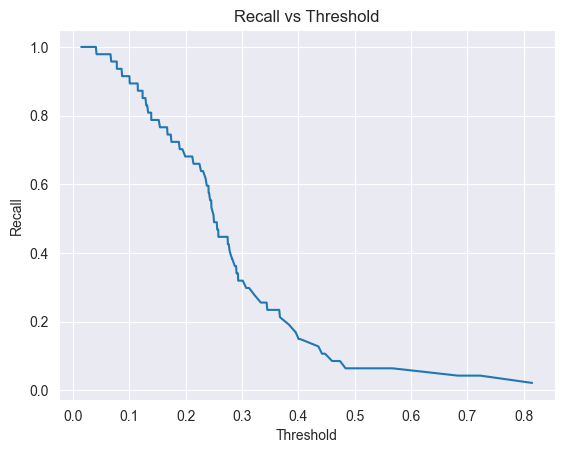

In [176]:
#adding a section with threshold
best_thr = evaluate_with_threshold(rf, X_test, y_test, target_recall=0.70)

Chosen Threshold: 0.132
Target Recall: 0.8

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            144         103
Actual: Attr                 8          39

ROC-AUC: 0.791024205357912
PR-AUC: 0.4247317796968544

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.58      0.72       247
           1       0.27      0.83      0.41        47

    accuracy                           0.62       294
   macro avg       0.61      0.71      0.57       294
weighted avg       0.84      0.62      0.67       294



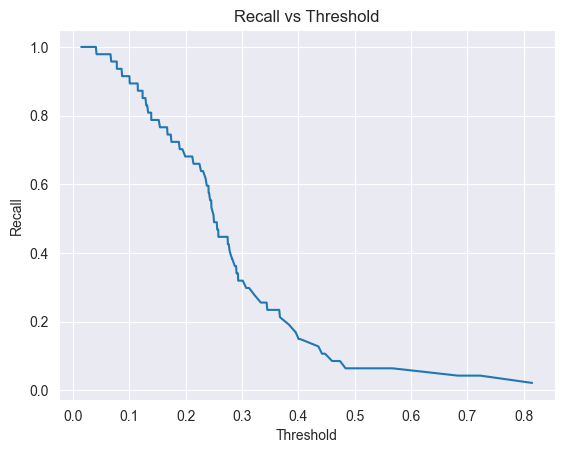

In [177]:
best_thr = evaluate_with_threshold(rf, X_test, y_test, target_recall=0.80)


We can now see that the lower thresholds significantly improve the recall for True positives.
For the intial metrics, RF captured only 13 positives. With a target recall of 70 or 80, we can see a big improvement of 34 and 39 true positives respectively.
The drawback of such a low treshold at a 80 recall target, is that too many false positives appear.
A 70% recall target seems to be ideal as it maximizes identification of true attrition while minimizing false positives.
Recall and Precision of No Attrition remains high as well.

In [178]:

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

MonthlyIncome           0.082119
Age                     0.075349
TotalWorkingYears       0.070911
OverTime                0.058298
YearsAtCompany          0.050126
DailyRate               0.047028
YearsWithCurrManager    0.042907
DistanceFromHome        0.042771
HourlyRate              0.039669
MonthlyRate             0.037597
dtype: float64


For feature importance, it seems compensation, tenure, and overtime play a large role.

Next algorithm is Xgboost


In [179]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

xgb = XGBClassifier(
)

xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("XGB PR-AUC (Avg Precision):", average_precision_score(y_test, xgb_proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, xgb_pred))
print("\nReport:\n", classification_report(y_test, xgb_pred, digits=3))

XGB ROC-AUC: 0.7664742871909725
XGB PR-AUC (Avg Precision): 0.4843323639973867

Confusion matrix:
 [[242   5]
 [ 37  10]]

Report:
               precision    recall  f1-score   support

           0      0.867     0.980     0.920       247
           1      0.667     0.213     0.323        47

    accuracy                          0.857       294
   macro avg      0.767     0.596     0.621       294
weighted avg      0.835     0.857     0.825       294



Chosen Threshold: 0.016
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            165          82
Actual: Attr                13          34

ROC-AUC: 0.7664742871909725
PR-AUC: 0.4843323639973867

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.67      0.78       247
           1       0.29      0.72      0.42        47

    accuracy                           0.68       294
   macro avg       0.61      0.70      0.60       294
weighted avg       0.83      0.68      0.72       294



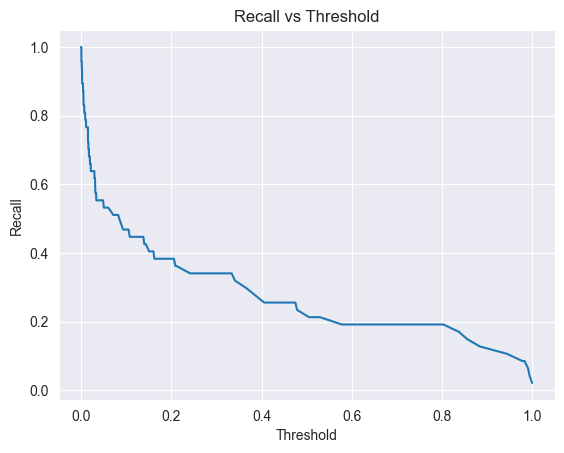

In [180]:
best_thr_xgb_normal = evaluate_with_threshold(xgb, X_test, y_test, target_recall=0.70)

In [181]:
xgb_sm = XGBClassifier(
)

xgb_sm.fit(X_sm, y_sm)

xgb_proba_sm = xgb_sm.predict_proba(X_test)[:, 1]
xgb_pred_sm = xgb_sm.predict(X_test)

print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_proba_sm))
print("XGB PR-AUC (Avg Precision):", average_precision_score(y_test, xgb_proba_sm))
print("\nConfusion matrix:\n", confusion_matrix(y_test, xgb_pred_sm))
print("\nReport:\n", classification_report(y_test, xgb_pred_sm, digits=3))

XGB ROC-AUC: 0.7526057369282453
XGB PR-AUC (Avg Precision): 0.4372657153801405

Confusion matrix:
 [[236  11]
 [ 36  11]]

Report:
               precision    recall  f1-score   support

           0      0.868     0.955     0.909       247
           1      0.500     0.234     0.319        47

    accuracy                          0.840       294
   macro avg      0.684     0.595     0.614       294
weighted avg      0.809     0.840     0.815       294



Chosen Threshold: 0.017
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            158          89
Actual: Attr                13          34

ROC-AUC: 0.7526057369282453
PR-AUC: 0.4372657153801405

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.64      0.76       247
           1       0.28      0.72      0.40        47

    accuracy                           0.65       294
   macro avg       0.60      0.68      0.58       294
weighted avg       0.82      0.65      0.70       294



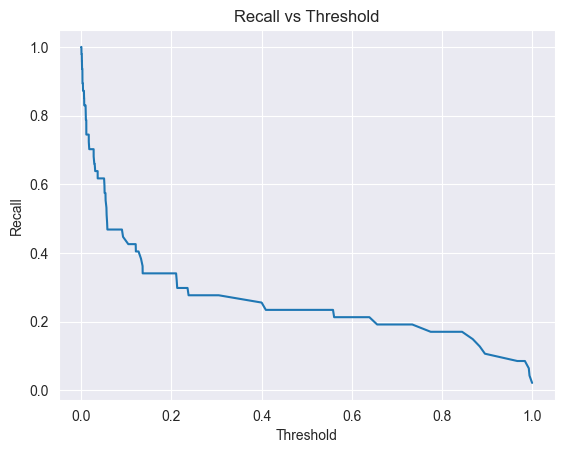

In [182]:
best_thr_xgb_sm = evaluate_with_threshold(xgb_sm, X_test, y_test, target_recall=0.70)


In [183]:
xgb_balanced = XGBClassifier(class_weight="balanced"
)

xgb_balanced.fit(X_train, y_train)

xgb_proba_balanced = xgb.predict_proba(X_test)[:, 1]
xgb_pred_balanced = xgb.predict(X_test)

print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_proba_balanced))
print("XGB PR-AUC (Avg Precision):", average_precision_score(y_test, xgb_proba_balanced))
print("\nConfusion matrix:\n", confusion_matrix(y_test, xgb_pred_balanced))
print("\nReport:\n", classification_report(y_test, xgb_pred_balanced, digits=3))

XGB ROC-AUC: 0.7664742871909725
XGB PR-AUC (Avg Precision): 0.4843323639973867

Confusion matrix:
 [[242   5]
 [ 37  10]]

Report:
               precision    recall  f1-score   support

           0      0.867     0.980     0.920       247
           1      0.667     0.213     0.323        47

    accuracy                          0.857       294
   macro avg      0.767     0.596     0.621       294
weighted avg      0.835     0.857     0.825       294



In [184]:

xgb_importances = (
    pd.Series(xgb.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False)
)

print(xgb_importances.head(10))


TotalWorkingYears                  0.057987
JobRole_Sales Executive            0.051324
StockOptionLevel                   0.048075
EducationField_Technical Degree    0.047660
OverTime                           0.046321
JobRole_Research Scientist         0.044655
MaritalStatus_Divorced             0.033816
EnvironmentSatisfaction            0.033344
YearsWithCurrManager               0.032277
Age                                0.031349
dtype: float32


In [185]:
xgb_importances = (
    pd.Series(xgb.feature_importances_, index=X_sm.columns)
      .sort_values(ascending=False)
)

print(xgb_importances.head(10))

TotalWorkingYears                  0.057987
JobRole_Sales Executive            0.051324
StockOptionLevel                   0.048075
EducationField_Technical Degree    0.047660
OverTime                           0.046321
JobRole_Research Scientist         0.044655
MaritalStatus_Divorced             0.033816
EnvironmentSatisfaction            0.033344
YearsWithCurrManager               0.032277
Age                                0.031349
dtype: float32


In [186]:
xgb_importances = (
    pd.Series(xgb_balanced.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False)
)

print(xgb_importances.head(10))

TotalWorkingYears                  0.057987
JobRole_Sales Executive            0.051324
StockOptionLevel                   0.048075
EducationField_Technical Degree    0.047660
OverTime                           0.046321
JobRole_Research Scientist         0.044655
MaritalStatus_Divorced             0.033816
EnvironmentSatisfaction            0.033344
YearsWithCurrManager               0.032277
Age                                0.031349
dtype: float32


Moving on to decision tree

In [187]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report


dt_balanced = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train, y_train)


proba = dt_balanced.predict_proba(X_test)[:,1]
pred = dt_balanced.predict(X_test)

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, proba))
print("DT PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

Decision Tree ROC-AUC: 0.6489792402446378
DT PR-AUC (Avg Precision): 0.3170636221720866

Confusion matrix:
 [[205  42]
 [ 22  25]]

Report:
               precision    recall  f1-score   support

           0      0.903     0.830     0.865       247
           1      0.373     0.532     0.439        47

    accuracy                          0.782       294
   macro avg      0.638     0.681     0.652       294
weighted avg      0.818     0.782     0.797       294



Chosen Threshold: 0.147
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr             28         219
Actual: Attr                 7          40

ROC-AUC: 0.6489792402446378
PR-AUC: 0.3170636221720866

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.11      0.20       247
           1       0.15      0.85      0.26        47

    accuracy                           0.23       294
   macro avg       0.48      0.48      0.23       294
weighted avg       0.70      0.23      0.21       294



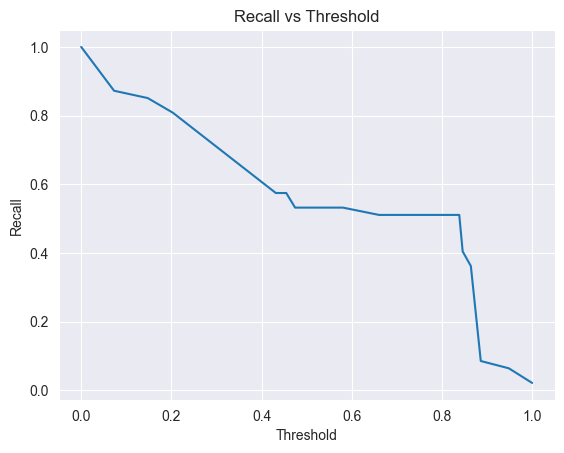

In [188]:
best_thr_balanced = evaluate_with_threshold(dt_balanced, X_test, y_test, target_recall=0.70)

For DT it seems the threshold may be too negatively impactful. Recall increased to 85 with a target recall of 70, but accuracy, class 0 recall, and false positives are very high.
Trying with lower tresholds or sticking with default.


In [189]:
#DT with normal weight class
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report


dt_standard = DecisionTreeClassifier(
    max_depth=5,
    # class_weight="balanced",
    random_state=42
)

dt_standard.fit(X_train, y_train)


proba = dt_standard.predict_proba(X_test)[:,1]
pred = dt_standard.predict(X_test)

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, proba))
print("DT PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

Decision Tree ROC-AUC: 0.6618141097424413
DT PR-AUC (Avg Precision): 0.2745513851882033

Confusion matrix:
 [[237  10]
 [ 38   9]]

Report:
               precision    recall  f1-score   support

           0      0.862     0.960     0.908       247
           1      0.474     0.191     0.273        47

    accuracy                          0.837       294
   macro avg      0.668     0.576     0.590       294
weighted avg      0.800     0.837     0.806       294



Chosen Threshold: 0.052
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr              6         241
Actual: Attr                 3          44

ROC-AUC: 0.6618141097424413
PR-AUC: 0.2745513851882033

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.02      0.05       247
           1       0.15      0.94      0.27        47

    accuracy                           0.17       294
   macro avg       0.41      0.48      0.16       294
weighted avg       0.58      0.17      0.08       294



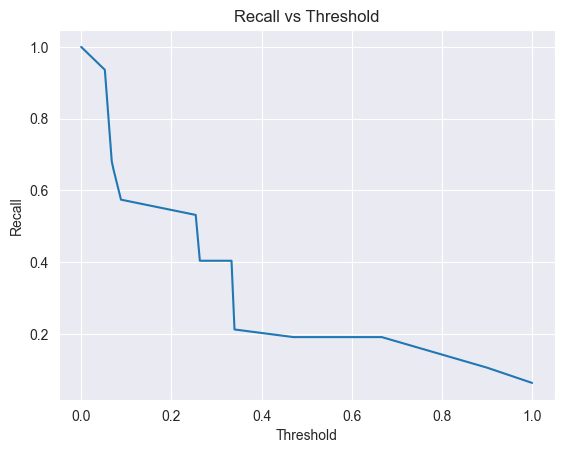

In [211]:
best_thr_standard = evaluate_with_threshold(dt_standard, X_test, y_test, target_recall=0.70)


In [201]:
#DT with SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report


dt_standard_sm = DecisionTreeClassifier(
    max_depth=5,
    # class_weight="balanced",
    random_state=42
)

dt_standard_sm.fit(X_sm, y_sm)


proba = dt_standard_sm.predict_proba(X_test)[:,1]
pred = dt_standard_sm.predict(X_test)

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, proba))
print("DT PR-AUC (Avg Precision):", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

Decision Tree ROC-AUC: 0.628391765009906
DT PR-AUC (Avg Precision): 0.25318537460281854

Confusion matrix:
 [[221  26]
 [ 35  12]]

Report:
               precision    recall  f1-score   support

           0      0.863     0.895     0.879       247
           1      0.316     0.255     0.282        47

    accuracy                          0.793       294
   macro avg      0.590     0.575     0.581       294
weighted avg      0.776     0.793     0.783       294



In [192]:
importances = pd.Series(dt_standard_sm.feature_importances_, index=X_sm.columns).sort_values(ascending=False)
print(importances.head(20))

MaritalStatus_Single                 0.444341
YearsWithCurrManager                 0.111553
StockOptionLevel                     0.076552
JobLevel                             0.072722
JobSatisfaction                      0.071805
JobRole_Laboratory Technician        0.043015
JobRole_Sales Executive              0.042187
WorkLifeBalance                      0.030848
EducationField_Medical               0.029504
JobInvolvement                       0.028336
DistanceFromHome                     0.025854
Department_Sales                     0.008809
MonthlyIncome                        0.005883
NumCompaniesWorked                   0.004892
DailyRate                            0.003699
EducationField_Other                 0.000000
EducationField_Technical Degree      0.000000
Gender_Female                        0.000000
JobRole_Healthcare Representative    0.000000
JobRole_Research Director            0.000000
dtype: float64


In [193]:
importances = pd.Series(dt_balanced.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

TotalWorkingYears     0.198218
OverTime              0.166605
Age                   0.106601
StockOptionLevel      0.100886
NumCompaniesWorked    0.094860
JobLevel              0.062221
DailyRate             0.033095
Department_Sales      0.031323
WorkLifeBalance       0.030547
DistanceFromHome      0.024875
dtype: float64


In [194]:
# importances = pd.Series(dt_standard.feature_importances_, index=X_sm.columns).sort_values(ascending=False)
# print(importances.head(20))

AdaBoost model

In [195]:
from sklearn.ensemble import AdaBoostClassifier


ada = AdaBoostClassifier(n_estimators=50,
                         learning_rate=1)


ada.fit(X_train, y_train)

ada_proba = ada.predict_proba(X_test)[:, 1]
ada_pred  = ada.predict(X_test)

print("AdaBoost ROC-AUC:", roc_auc_score(y_test, ada_proba))
print("AdaBoost PR-AUC (Avg Precision):", average_precision_score(y_test, ada_proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, ada_pred))
print("\nReport:\n", classification_report(y_test, ada_pred, digits=3))

AdaBoost ROC-AUC: 0.799552071668533
AdaBoost PR-AUC (Avg Precision): 0.44931006890543845

Confusion matrix:
 [[233  14]
 [ 36  11]]

Report:
               precision    recall  f1-score   support

           0      0.866     0.943     0.903       247
           1      0.440     0.234     0.306        47

    accuracy                          0.830       294
   macro avg      0.653     0.589     0.604       294
weighted avg      0.798     0.830     0.808       294



In [196]:
from sklearn.ensemble import AdaBoostClassifier


ada_sm = AdaBoostClassifier(n_estimators=50,
                         learning_rate=1)


ada_sm.fit(X_sm, y_sm)

ada_proba = ada.predict_proba(X_test)[:, 1]
ada_pred  = ada.predict(X_test)

print("AdaBoost ROC-AUC:", roc_auc_score(y_test, ada_proba))
print("AdaBoost PR-AUC (Avg Precision):", average_precision_score(y_test, ada_proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, ada_pred))
print("\nReport:\n", classification_report(y_test, ada_pred, digits=3))

AdaBoost ROC-AUC: 0.799552071668533
AdaBoost PR-AUC (Avg Precision): 0.44931006890543845

Confusion matrix:
 [[233  14]
 [ 36  11]]

Report:
               precision    recall  f1-score   support

           0      0.866     0.943     0.903       247
           1      0.440     0.234     0.306        47

    accuracy                          0.830       294
   macro avg      0.653     0.589     0.604       294
weighted avg      0.798     0.830     0.808       294



Chosen Threshold: 0.422
Target Recall: 0.7

Confusion Matrix (thresholded):
                  Pred: No Attr  Pred: Attr
Actual: No Attr            182          65
Actual: Attr                13          34

ROC-AUC: 0.799552071668533
PR-AUC: 0.44931006890543845

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.74      0.82       247
           1       0.34      0.72      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.73      0.77       294



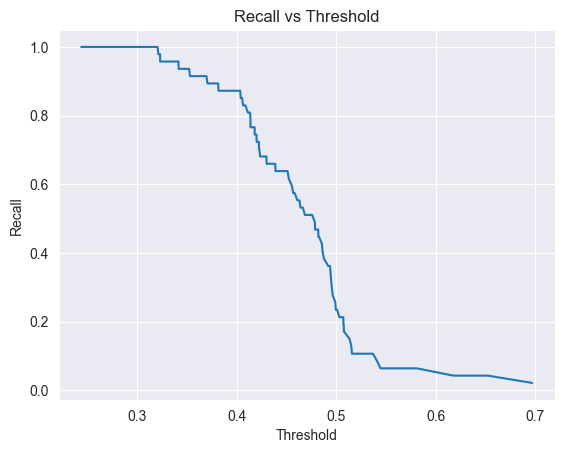

In [197]:
best_thr_ada = evaluate_with_threshold(ada, X_test, y_test, target_recall=0.70)


In [198]:
ada_importances = pd.Series(ada.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(ada_importances.head(15))

TotalWorkingYears             0.156546
MonthlyIncome                 0.095735
JobInvolvement                0.068543
NumCompaniesWorked            0.067802
OverTime                      0.067146
BusinessTravel                0.060346
WorkLifeBalance               0.038754
StockOptionLevel              0.037981
Age                           0.035619
EnvironmentSatisfaction       0.033995
DailyRate                     0.033178
YearsWithCurrManager          0.031627
JobRole_Research Director     0.029929
RelationshipSatisfaction      0.029718
JobRole_Research Scientist    0.028294
dtype: float64
